In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px

#Ingestion/Exploratory Data Analysis (EDA)

###Loading in and exploring the Incidents data

In [ ]:
incidents_df = pd.read_csv('Crash_Reporting_Incidents_Data_20260407.csv') #loading in the first dataset and checking the first few lines
incidents_df.head()

/tmp/ipykernel_26753/1963095630.py:1: DtypeWarning: Columns (1,9,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  incidents_df = pd.read_csv('Crash_Reporting_Incidents_Data_20260407.csv') #loading in the first dataset and checking the first few lines


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Hit/Run,Route Type,Lane Direction,Lane Type,Number of Lanes,...,First Harmful Event,Second Harmful Event,Junction,Intersection Type,Road Alignment,Road Condition,Road Division,Latitude,Longitude,Location
0,MCP26510051,260013422,MONTGOMERY,Property Damage Crash,03/28/2026 09:10:00 PM,NaN,Other Public Roadway,Northbound,Lane 1,1,...,Parked Vehicle,Not Applicable,Non-Junction,NaN,Straight,No Defects,Not Divided,39.167809,-77.182975,"(39.1678095, -77.18297467)"
1,EJ78880091,260013399,GAITHERSBURG,Property Damage Crash,03/28/2026 06:52:00 PM,NaN,NaN,NaN,NaN,0,...,Parked Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,39.150114,-77.191244,"(39.15011419, -77.19124427)"
2,MCP235800FK,260013346,MONTGOMERY,Property Damage Crash,03/28/2026 12:00:00 PM,No,Local Route,Eastbound,"Lane 1, Not Applicable",1,...,Motor Vehicle In Transport,NaN,Intersection or Related,Perpendicular,Straight,No Defects,Not Divided,39.043276,-77.114795,"(39.04327621, -77.11479486)"
3,MCP320000HF,260013348,MONTGOMERY,Property Damage Crash,03/28/2026 11:27:00 AM,No,NaN,NaN,NaN,0,...,Curb,"Other Fixed Object (wall, building, tunnel, etc.)",NaN,NaN,NaN,NaN,NaN,39.017845,-77.208213,"(39.01784503, -77.20821304)"
4,MCP3288003G,260013298,MONTGOMERY,Property Damage Crash,03/27/2026 10:13:00 PM,No,County Route,"Northbound, Westbound",Lane 1,2,...,Motor Vehicle In Transport,NaN,Intersection or Related,Perpendicular,Straight,No Defects,"Divided, Raised Median (curbed), Not Divided",39.174662,-77.203578,"(39.1746625, -77.203578)"


In [ ]:
incidents_df.info() #checking the dimensions and basic info on the dataset columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120440 entries, 0 to 120439
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Report Number                 120440 non-null  object 
 1   Local Case Number             120440 non-null  object 
 2   Agency Name                   120440 non-null  object 
 3   ACRS Report Type              120440 non-null  object 
 4   Crash Date/Time               120440 non-null  object 
 5   Hit/Run                       116086 non-null  object 
 6   Route Type                    104515 non-null  object 
 7   Lane Direction                105116 non-null  object 
 8   Lane Type                     29564 non-null   object 
 9   Number of Lanes               108101 non-null  object 
 10  Direction                     105174 non-null  object 
 11  Distance                      107037 non-null  object 
 12  Distance Unit                 108113 non-nul

In [ ]:
incidents_df.isnull().sum() #checking for missing values

,0
Report Number,0
Local Case Number,0
Agency Name,0
ACRS Report Type,0
Crash Date/Time,0
Hit/Run,4354
Route Type,15925
Lane Direction,15324
Lane Type,90876
Number of Lanes,12339


In [ ]:
incidents_df.drop(columns=['Latitude','Longitude', 'Location']).describe() #descriptive statistics only for the categorical columns

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Hit/Run,Route Type,Lane Direction,Lane Type,Number of Lanes,...,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,First Harmful Event,Second Harmful Event,Junction,Intersection Type,Road Alignment,Road Condition,Road Division
count,120440,120440,120440,120440,120440,116086,104515,105116,29564,108101.0,...,101110,104694,5696,119790,30348,90859,54626,104764,99864,103984
unique,120440,120325,10,3,117493,2,19,39,210,119.0,...,85,115,27,67,64,22,11,12,21,36
top,MCP11520005,220044049,Montgomery County Police,Property Damage Crash,05/22/2015 09:55:00 PM,No,Maryland (State),North,Lane 1,2.0,...,NO CONTROLS,NONE DETECTED,NONE DETECTED,OTHER VEHICLE,OTHER VEHICLE,INTERSECTION,FOUR-WAY INTERSECTION,STRAIGHT,NO DEFECTS,"TWO-WAY, DIVIDED, POSITIVE MEDIAN BARRIER"
freq,1,2,78093,79547,5,97535,39121,25905,8634,25628.0,...,41605,60777,3812,66578,12119,32164,30613,74048,80463,39861


### Creating simple countplots to explore important columns that I'll use in my analysis  

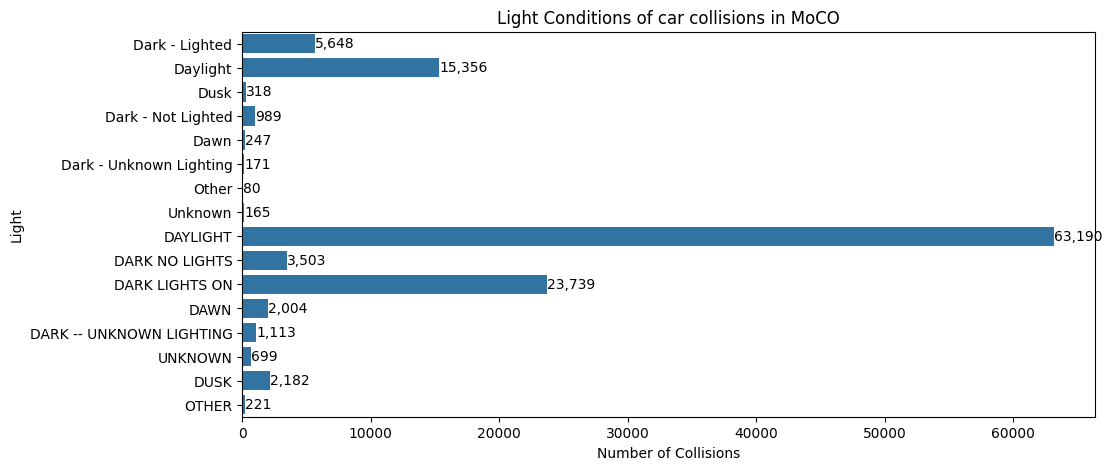

In [ ]:
plt.figure(figsize=(11,5))
p3 = sn.countplot(y="Light", data = incidents_df)
plt.title("Light Conditions of car collisions in MoCO")
plt.xlabel("Number of Collisions")
for container in p3.containers:       #to display the actual values with commas next to the bar graphs
    p3.bar_label(container, fmt= '{:,.0f}')
plt.show()

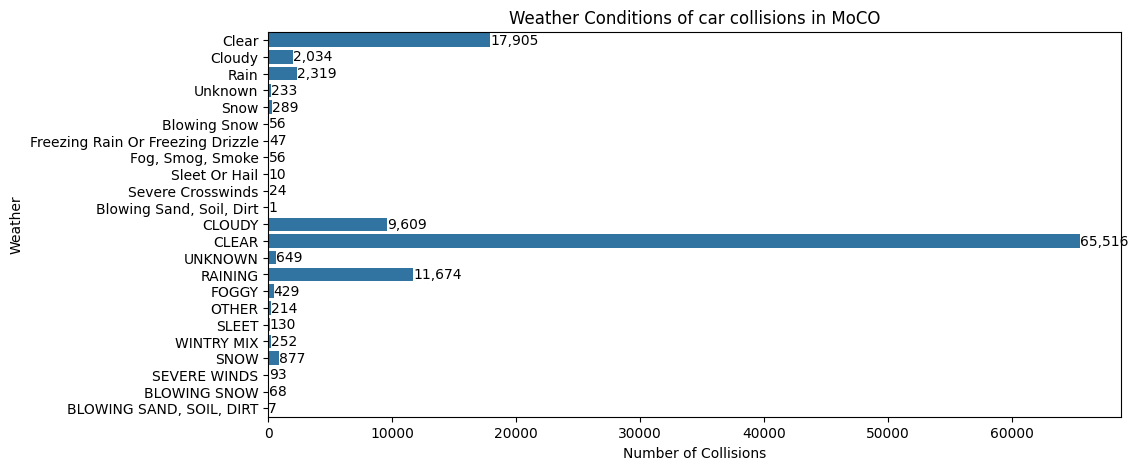

In [ ]:
plt.figure(figsize=(11,5))
p4 = sn.countplot(y="Weather", data = incidents_df)
plt.title("Weather Conditions of car collisions in MoCO")
plt.xlabel("Number of Collisions")
for container in p4.containers:       #to display the actual values with commas next to the bar graphs
    p4.bar_label(container, fmt= '{:,.0f}')
plt.show()

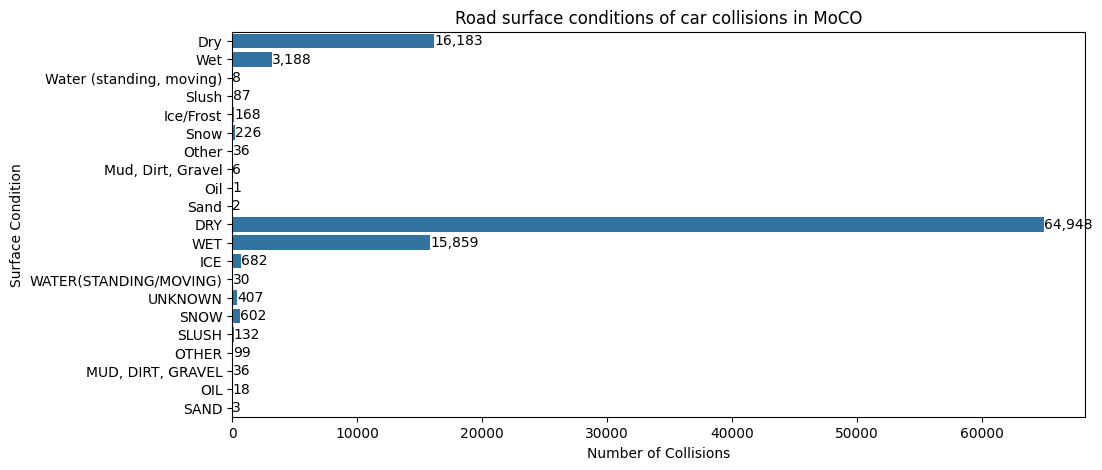

In [ ]:
plt.figure(figsize=(11,5))
p5 = sn.countplot(y="Surface Condition", data = incidents_df)
plt.title("Road surface conditions of car collisions in MoCO")
plt.xlabel("Number of Collisions")
for container in p5.containers:       #to display the actual values with commas next to the bar graphs
    p5.bar_label(container, fmt= '{:,.0f}')
plt.show()

These three exploratory countplots alongside others, show some of the columns that have to be cleaned. To clean them, I will make the entire values of such  columns lowercase to eliminate different versions of the same categorical value

In [ ]:
cols_to_clean = ['Light', 'Weather', 'Surface Condition', 'Collision Type']
for col in cols_to_clean:
  incidents_df[col] = incidents_df[col].str.lower()
incidents_df["Weather"] = incidents_df["Weather"].replace({'raining': 'rain', 'blowing snow': 'snow','foggy':'fog, smog, smoke', 'sleet':'sleet or hail', 'severe crosswinds':'severe winds', 'freezing rain or freezing drizzle':'wintry mix'})

To show the effect of the cleaning, I will make the weather condition count plot again. As we can see below, this was successfull. For example, the two versions of the value "clear" added up to 83,000. In other terms, the number of distinct categorical values for the weather column dropped to 17 from 23.

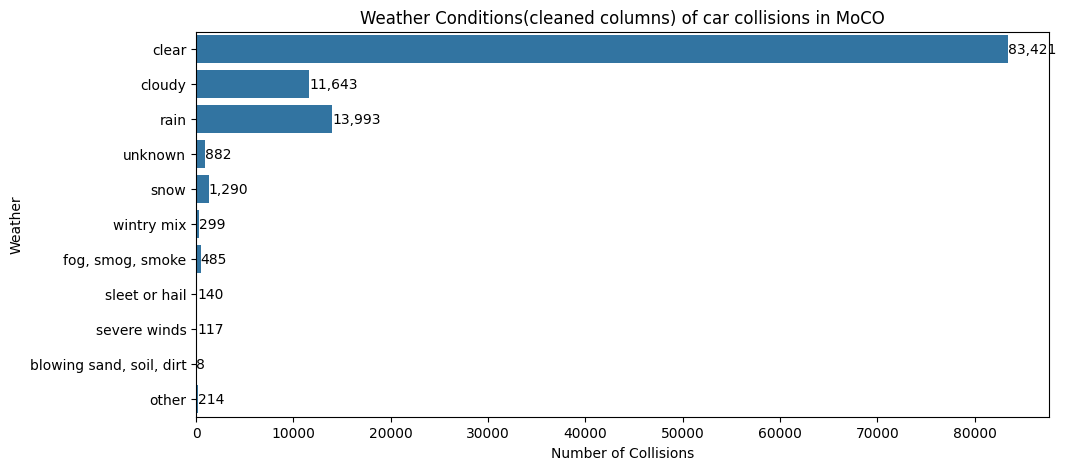

In [ ]:
plt.figure(figsize=(11,5))
p4 = sn.countplot(y="Weather", data = incidents_df)
plt.title("Weather Conditions(cleaned columns) of car collisions in MoCO")
plt.xlabel("Number of Collisions")
for container in p4.containers:       #to display the actual values with commas next to the bar graphs
    p4.bar_label(container, fmt= '{:,.0f}')
plt.show()

###Loading in and exploring the Drivers datset

In [ ]:
drivers_df = pd.read_csv('Crash_Reporting_Drivers_Data_20260407.csv') #loading in the second dataset and checking the first few lines
drivers_df.head()

/tmp/ipykernel_9106/3988527414.py:1: DtypeWarning: Columns (1,9) have mixed types. Specify dtype option on import or set low_memory=False.
  drivers_df = pd.read_csv('Crash_Reporting_Drivers_Data_20260407.csv') #loading in the second dataset and checking the first few lines


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP26510051,260013422,MONTGOMERY,Property Damage Crash,03/28/2026 09:10:00 PM,Other Public Roadway,QUAIL VALLEY BLVD,NaN,NaN,NaN,...,Southbound,25,No,No,2005,FORD,MUSTANG,39.167809,-77.182975,"(39.1678095, -77.18297467)"
1,EJ78880091,260013399,GAITHERSBURG,Property Damage Crash,03/28/2026 06:52:00 PM,NaN,NaN,NaN,Parking Aisle PARKING LOT OF 394 N SUMM...,NaN,...,Unknown,0,No,No,2004,HONDA,PILOT,39.150114,-77.191244,"(39.15011419, -77.19124427)"
2,MCP235800FK,260013346,MONTGOMERY,Property Damage Crash,03/28/2026 12:00:00 PM,Local Route,RIDGEROCK LA,EXECUTIVE BLVD,NaN,NaN,...,NaN,35,No,No,2018,INFINITI,Q70L,39.043276,-77.114795,"(39.04327621, -77.11479486)"
3,MCP235800FK,260013346,MONTGOMERY,Property Damage Crash,03/28/2026 12:00:00 PM,Local Route,RIDGEROCK LA,EXECUTIVE BLVD,NaN,NaN,...,NaN,35,No,No,2009,NISSAN,VERSA,39.043276,-77.114795,"(39.04327621, -77.11479486)"
4,MCP320000HF,260013348,MONTGOMERY,Property Damage Crash,03/28/2026 11:27:00 AM,NaN,NaN,NaN,Parking Lot Way PARKING LOT IN FRONT OF...,NaN,...,Westbound,0,No,No,2012,HYUNDAI,SONATA,39.017845,-77.208213,"(39.01784503, -77.20821304)"


In [ ]:
drivers_df.info() #checking the dimesions and basic info on the dataset columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212210 entries, 0 to 212209
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Report Number                  212210 non-null  object 
 1   Local Case Number              212210 non-null  object 
 2   Agency Name                    212210 non-null  object 
 3   ACRS Report Type               212210 non-null  object 
 4   Crash Date/Time                212210 non-null  object 
 5   Route Type                     191423 non-null  object 
 6   Road Name                      187532 non-null  object 
 7   Cross-Street Name              170776 non-null  object 
 8   Off-Road Description           19745 non-null   object 
 9   Municipality                   19126 non-null   object 
 10  Related Non-Motorist           6918 non-null    object 
 11  Collision Type                 211625 non-null  object 
 12  Weather                       

In [ ]:
drivers_df.isnull().sum() #checking for missing values

,0
Report Number,0
Local Case Number,0
Agency Name,0
ACRS Report Type,0
Crash Date/Time,0
Route Type,20787
Road Name,24678
Cross-Street Name,41434
Off-Road Description,192465
Municipality,193084


In [ ]:
drivers_df.drop(columns=['Speed Limit', 'Vehicle Year', 'Latitude', 'Longitude', 'Location']).describe() #descriptive statistics for the categorical columns

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Driverless Vehicle,Parked Vehicle,Vehicle Make,Vehicle Model
count,212210,212210,212210,212210,212210,191423,187532,170776,19745,19126,...,212210,211894,212054,208973,210491,202427,212210,210684,211038,210996
unique,119687,119602,10,3,116767,19,4815,7550,14092,20,...,212210,12,33,60,36,10,2,2,1965,7190
top,MCP229800RC,200022715,Montgomery County Police,Property Damage Crash,12/10/2018 06:10:00 PM,Maryland (State),GEORGIA AVE,GEORGIA AVE,PARKING LOT,ROCKVILLE,...,EED35F71-B94E-4225-98D4-3405AEA57D0B,DISABLING,TWELVE OCLOCK,PASSENGER CAR,MOVING CONSTANT SPEED,North,No,No,TOYOTA,4S
freq,10,10,138376,136320,11,77077,11807,2394,132,9320,...,1,62354,68025,119109,67240,47647,211457,207136,30862,13753


## Research questions

### What was the most common type of car collision incident?
To answer this question I will make a simple countplot of the "ACRS report type" column from the Incidents data.
I'm not using Drivers data here becuase each row is a driver in that dataset and there can be multiple drivers involved in a single collision which means the type of report will be repeated for each driver so it will be inaccurate.  

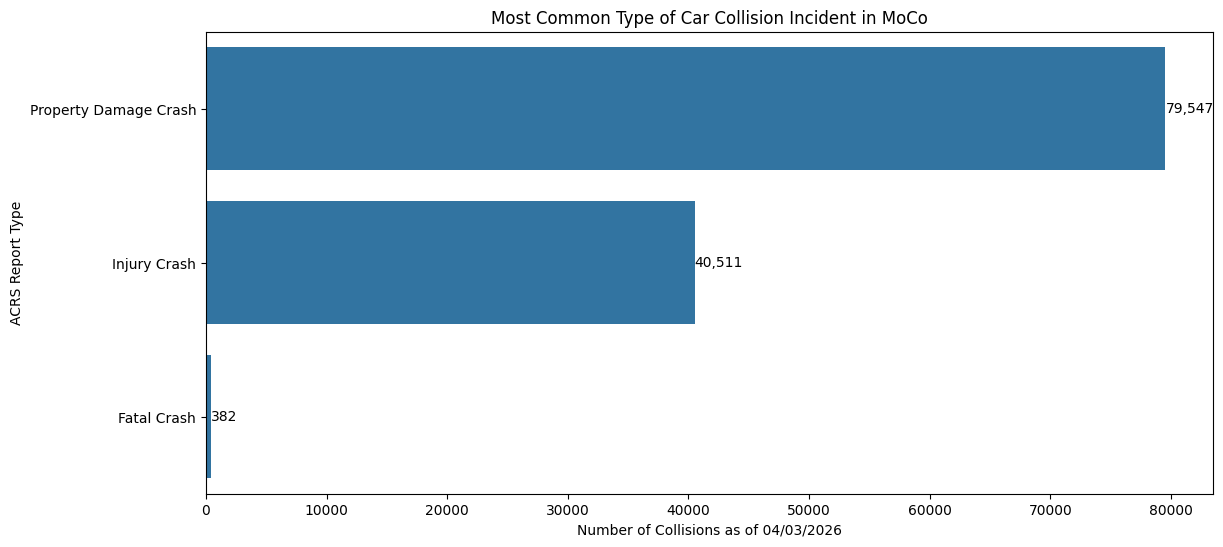

In [ ]:
plt.figure(figsize=(13,6))
p1 = sn.countplot(y = "ACRS Report Type", data = incidents_df)
plt.title("Most Common Type of Car Collision Incident in MoCo")
plt.xlabel("Number of Collisions as of 04/03/2026")
for container in p1.containers:    #to display the actual values with commas next to the bar graphs
    p1.bar_label(container, fmt='{:,.0f}')
plt.show()

### Which roads have seen the most collision incidents?
I will make a simple countplot to answer this question. To make it slightly different from the inital version, I will add the factor of collision type.

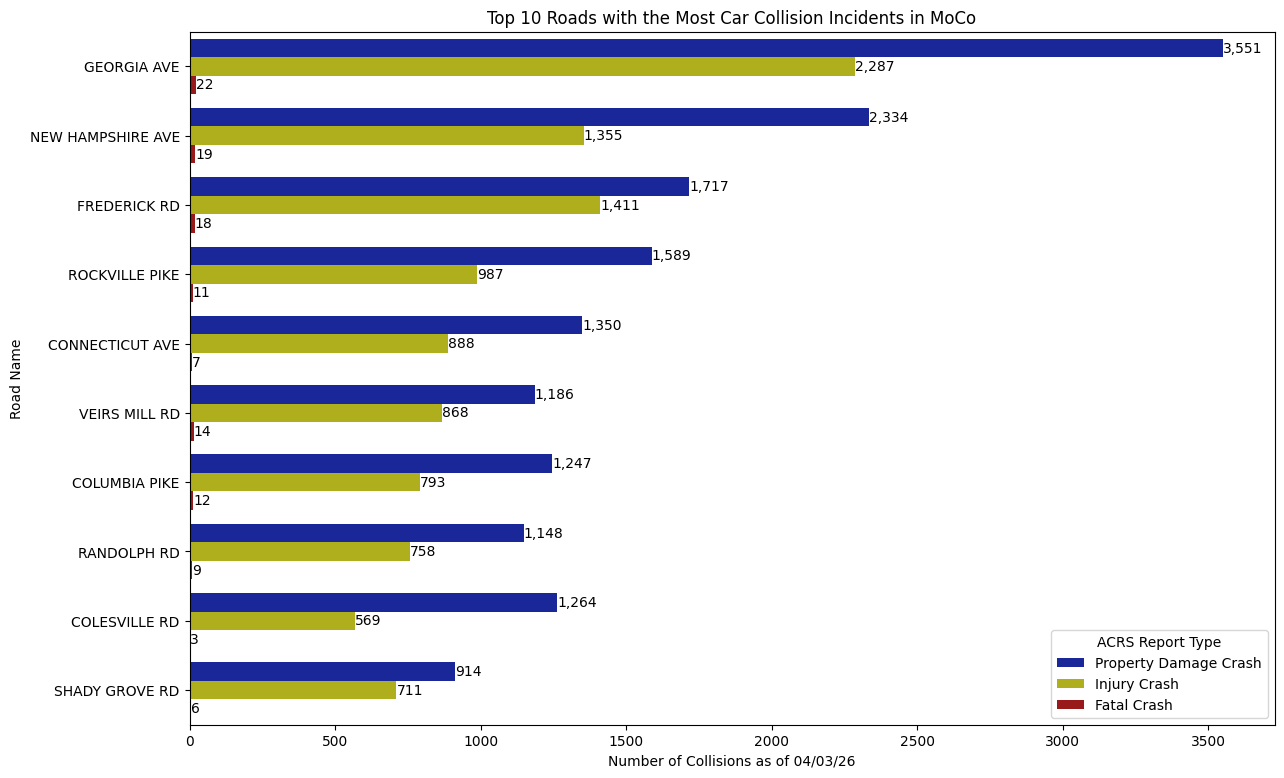

In [ ]:
top10_roads = incidents_df[incidents_df['Road Name'].isin(incidents_df['Road Name'].value_counts().head(10).index)]
plt.figure(figsize=(14,9))
p2 = sn.countplot(y = "Road Name", data = top10_roads, hue='ACRS Report Type',palette=['#0516ad', '#c7c706', '#ad0505'], order = top10_roads["Road Name"].value_counts().index)
plt.title("Top 10 Roads with the Most Car Collision Incidents in MoCo")
plt.xlabel("Number of Collisions as of 04/03/26")
for container in p2.containers:       #to display the actual values with commas next to the bar graphs
    p2.bar_label(container, fmt='{:,.0f}')
plt.show()

###How has the number of car collision incidents changed over time since 2015?
To answer this question I will make a time series line graph. There is a very noticable sharp decline of car collsions in 2020 as a result of Covid-19. Additionally, there is a repeated up and down pattern happening throughout the whole series. This opens up a new path for exploration.

/tmp/ipykernel_26753/4011130281.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = incidents_df.resample('M').size()


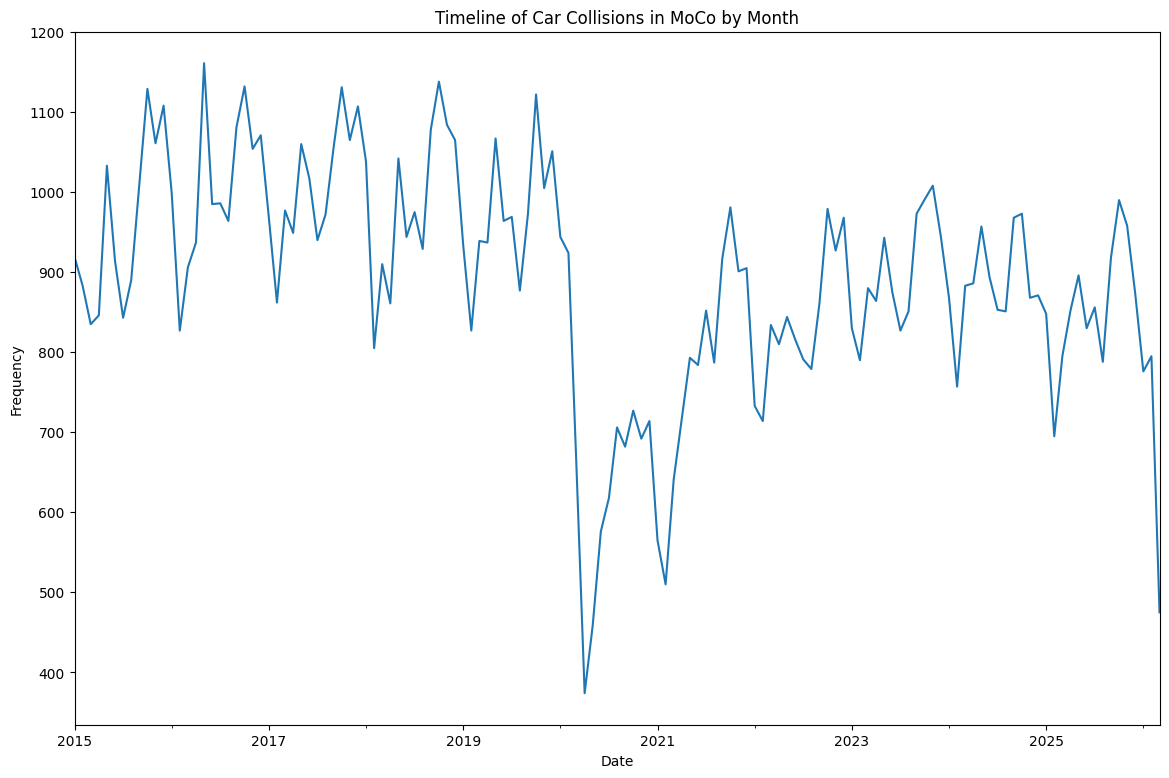

In [ ]:

#incidents_df['Crash Date/Time'] = pd.to_datetime(incidents_df['Crash Date/Time'], format='%m/%d/%Y %I:%M:%S %p')
#incidents_df.set_index('Crash Date/Time', inplace=True)
plt.figure(figsize=(14,9))
monthly_counts = incidents_df.resample('M').size()
monthly_counts.plot(kind='line', title='Timeline of Car Collisions in MoCo by Month')
plt.ylabel('Frequency')
plt.xlabel('Date')
plt.show()